Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## **Question 1**

Defining functions for solving ODE

In [2]:
# Euler
def euler(f, x, y, h):
    return y + h*f(x, y)

# Midpoint
def midpoint(f, x, y, h):
    k1 = h*f(x, y)
    return y + h*f(x + h/2, y + k1/2)

# RK4
def rk4(f, x, y, h):
    k1 = f(x, y)
    k2 = f(x + h/2, y + h*k1/2)
    k3 = f(x + h/2, y + h*k2/2)
    k4 = f(x + h, y + h*k3)

    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# Function for calling different methods
def caller(f, xs, y0, N, h, method):
    y = y0
    ys = np.zeros((N, len(y0)))

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(f, x, y, h)
    
    return ys

Defining the function to solve

$\frac{dx}{dt} = -x t = f(t, x)$

Function obtained after solving ODE analytically

$x(t) = e^{-\frac{t^2}{2}}$

In [3]:
# f(t, x) = dx/dt = -x*t
def f1(t, x):
    return -x*t

# The function obtained after solving the differential equation analytically
def exact1(t):
    return np.exp(-t**2/2)

**Part (a)**

Obtaining the exact, Euler and Midpoint solutions

In [4]:
# Defining parameters
h = 0.01
ti, tf = 0, 15      
xi = np.array([1])      # Passing yi as an array to match numpy array condition of caller
methods = [euler, midpoint]

# Obtaining the exact solution
N = int((tf - ti)/h) + 1
ts = ti + h*np.arange(N)

exact1s = exact1(ts)      # 1D array containing the exact y values at different x values
errors_a = np.zeros((N, len(methods)))      # Array for storing errors of the methods

# Obtaining the euler and midpoint solutions
xs1 = np.zeros((N, len(methods)))
for i in range(len(methods)):
    xs1[:, i] = caller(f1, ts, xi, N, h, methods[i])[:, 0]
    errors_a[:, i] = (xs1[:, i] - exact1s)
    
# ys1 has the y values at different x values as rows and the different methods as columns

Plotting the solutions

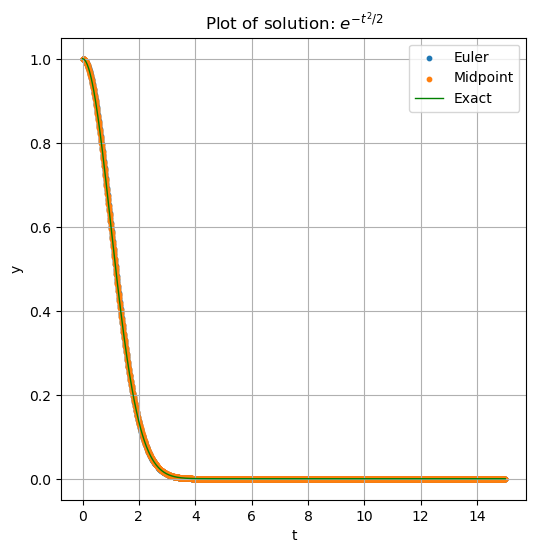

In [5]:
labels = ["Euler", "Midpoint", "RK4"]
plt.figure(figsize=(6, 6))

for i in range(len(methods)):
    plt.scatter(ts, xs1[:, i], s = 10, label = labels[i])

plt.plot(ts, exact1s, linewidth = 1, color = "green", label = "Exact")
plt.xlabel("t")
plt.ylabel("y")
plt.title(r"Plot of solution: $e^{-t^2/2}$")

plt.grid()
plt.legend()
plt.show()

Plotting the errors of different methods

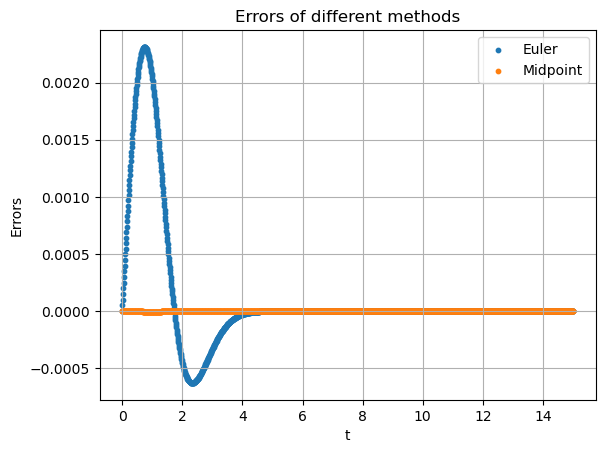

In [6]:
for i in range(len(methods)):
    plt.scatter(ts, errors_a[:, i], s = 10, label = labels[i])

plt.xlabel("t")
plt.ylabel("Errors")
plt.title("Errors of different methods")

plt.grid()
plt.legend()
plt.show()

**Part (b)**

Calculating errors for different h

In [7]:
# Defining Parameters
ni, nf = -4, -2
step = 0.2

# Array of h values
hs = 10.0 ** np.arange(ni, nf + step, step)
errors = np.zeros((len(hs), len(methods)))
xf_hs1 = np.zeros((len(hs), len(methods)))

# Final y point of exact solution
exact_final = exact1(tf)

# Calculating errors for different h values for different methods
for i in range(len(hs)):
    h = hs[i]
    N = int((tf - ti)/h) + 1
    ts = ti + h*np.arange(N)

    for j in range(len(methods)):
        xs_method = caller(f1, ts, xi, N, h, methods[j])[:, 0]
        xf_hs1[i, j] = xs_method[-1]
        errors[i, j] = abs(xs_method[-1] - exact_final)

Viewing the end points data in Pandas Dataframe

In [8]:
exact_final_arr = np.array([exact_final]*len(hs))       # 1D array having final exact point for last column of df
data1 = np.column_stack((hs, xf_hs1, exact_final_arr))        # Data of dataframe

col_names = [f"{labels[i]}" for i in range(len(methods))]
col_names.append("Exact")
col_names.insert(0, "h")

df1 = pd.DataFrame(data1, columns=col_names)
df1

,h,Euler,Midpoint,Exact
0,0.000100,1.311443e-49,1.386372e-49,1.386343e-49
1,0.000158,1.271294e-49,1.388400e-49,1.386343e-49
2,0.000251,1.205967e-49,1.386921e-49,1.386343e-49
3,0.000398,1.112749e-49,1.389260e-49,1.386343e-49
4,0.000631,9.788325e-50,1.392734e-49,1.386343e-49
5,0.001000,8.045935e-50,1.410252e-49,1.386343e-49
6,0.001585,5.741365e-50,1.405698e-49,1.386343e-49
7,0.002512,3.426766e-50,1.437617e-49,1.386343e-49
8,0.003981,1.495412e-50,1.507369e-49,1.386343e-49
9,0.006310,3.625736e-51,1.562796e-49,1.386343e-49


Plotting the errors

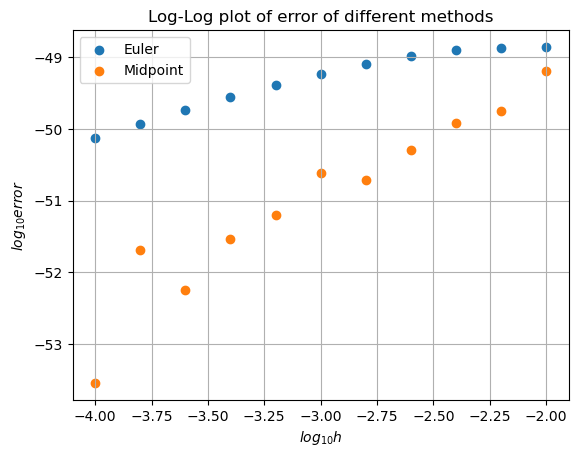

In [9]:
log_hs = np.log10(hs)
log_errors = np.log10(errors)

for i in range(len(methods)):
    plt.scatter(log_hs, log_errors[:, i], label = labels[i])
    # plt.scatter(hs, errors[:, i], label = labels[i])    # Use this to view Error vs h plot

plt.xlabel("$log_{10} h$")
plt.ylabel("$log_{10} error$")
plt.title("Log-Log plot of error of different methods")
plt.legend()
plt.grid()
plt.show()

**Part (c)**

Fitting log error vs log h

In [10]:
def eqn_of_line(x, m, c):
    return m*x + c

slopes, intercepts = [], []

for i in range(len(methods)):
    popt, pcov = curve_fit(eqn_of_line, log_hs, log_errors[:, i])
        
    slope, intercept = popt
    slopes.append(slope)
    intercepts.append(intercept)

Plotting the errors and fit

**Euler Method:**

Slope is close to 1 $\implies \log_{10} \text{error} = \log_{10} h \implies$ Error $\propto$ $h$

**Midpoint Method:**

Slope is close to 2 $\implies \log_{10} \text{error} = 2 \log_{10} h \implies$ Error $\propto$ $h^2$

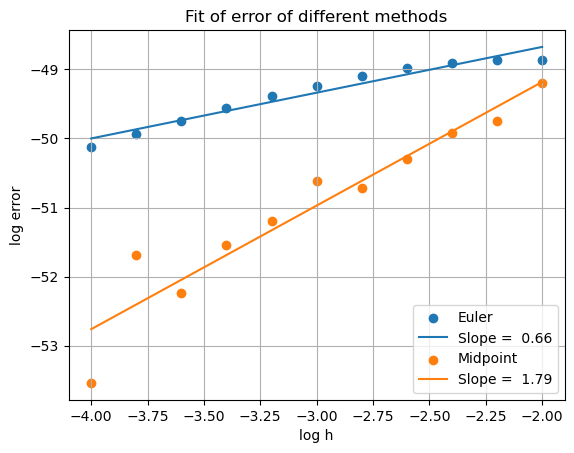

In [11]:
for i in range(len(methods)):
    plt.scatter(log_hs, log_errors[:, i], label = labels[i])
    plt.plot(log_hs, eqn_of_line(log_hs, slopes[i], intercepts[i]), label = f"Slope = {slopes[i]: 0.2f}")

plt.xlabel("log h")
plt.ylabel("log error")
plt.title("Fit of error of different methods")
plt.legend()
plt.grid()
plt.show()

# Run method with h = 0.1 and tf = 5 to get more accurate slopes

## **Question 2**

**Part (a)**

*y = y[0]*

*p = y[1]*

$\frac{d}{dt} \begin{pmatrix} y[0] \\ y[1] \end{pmatrix} = \begin{pmatrix} y[1] \\ -4\pi y[0]^2 \end{pmatrix}$

Defining parameters and function

In [12]:
def f2(t, y):
    return np.asarray([y[1], -4*(np.pi**2)*y[0]])

# Exact solution obtained after solving the ODE analytically
def exact2(t):
    return np.asarray([np.cos(2*np.pi*t), -2*np.pi*np.sin(2*np.pi*t)]).T

# Defining parameters
h = 0.01
xi = np.array([1, 0])
ti, tf = 0, 15
N = int((tf - ti)/h) + 1

Solving through different methods and exact solution

In [13]:
methods = [euler, midpoint]
xs2 = np.zeros((N, len(xi), len(methods)))
# xs2 contains the y values at different x values as length, position and momentum as breadth and the different methods as width

ts = ti + h*np.arange(N)
exact2s = exact2(ts)        # exact2s contains 2 columns - position and momentum

for i in range(len(methods)):
    xs2[:, :, i] = caller(f2, ts, xi, N, h, methods[i])

Viewing data in pandas Dataframe

In [14]:
# Position
data2_p = np.column_stack((ts, xs2[:, 0, :], exact2s[:, 0]))
col_names = [f"{labels[i]}" for i in range(len(methods))]
col_names.append("Exact")
col_names.insert(0, "t")

df2_p = pd.DataFrame(data2_p, columns=col_names)
print(df2_p)
print()

# Momentum
data2_v = np.column_stack((ts, xs2[:, 1, :], exact2s[:, 0]))
df2_v = pd.DataFrame(data2_v, columns=col_names)
print(df2_v)

          t      Euler  Midpoint     Exact
0      0.00   1.000000  1.000000  1.000000
1      0.01   1.000000  0.998026  0.998027
2      0.02   0.996052  0.992108  0.992115
3      0.03   0.988156  0.982270  0.982287
4      0.04   0.976329  0.968550  0.968583
...     ...        ...       ...       ...
1496  14.96  17.729915  0.984955  0.968583
1497  14.97  18.168069  0.994884  0.982287
1498  14.98  18.536228  1.000882  0.992115
1499  14.99  18.832662  1.002924  0.998027
1500  15.00  19.055917  1.001003  1.000000

[1501 rows x 4 columns]

          t      Euler  Midpoint     Exact
0      0.00   0.000000  0.000000  1.000000
1      0.01  -0.394784 -0.394784  0.998027
2      0.02  -0.789568 -0.788010  0.992115
3      0.03  -1.182794 -1.178123  0.982287
4      0.04  -1.572903 -1.563582  0.968583
...     ...        ...       ...       ...
1496  14.96  43.815352  1.187336  0.968583
1497  14.97  36.815861  0.796148  0.982287
1498  14.98  29.643395  0.401812  0.992115
1499  14.99  22.325586  0.00

Plotting solutions along with exact solution

C:\Users\ARYA BASAK\AppData\Local\Temp\ipykernel_22552\2147952819.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(ts, xs2[:, i, j], 'r--', color = colors[j], label = method_names[j])


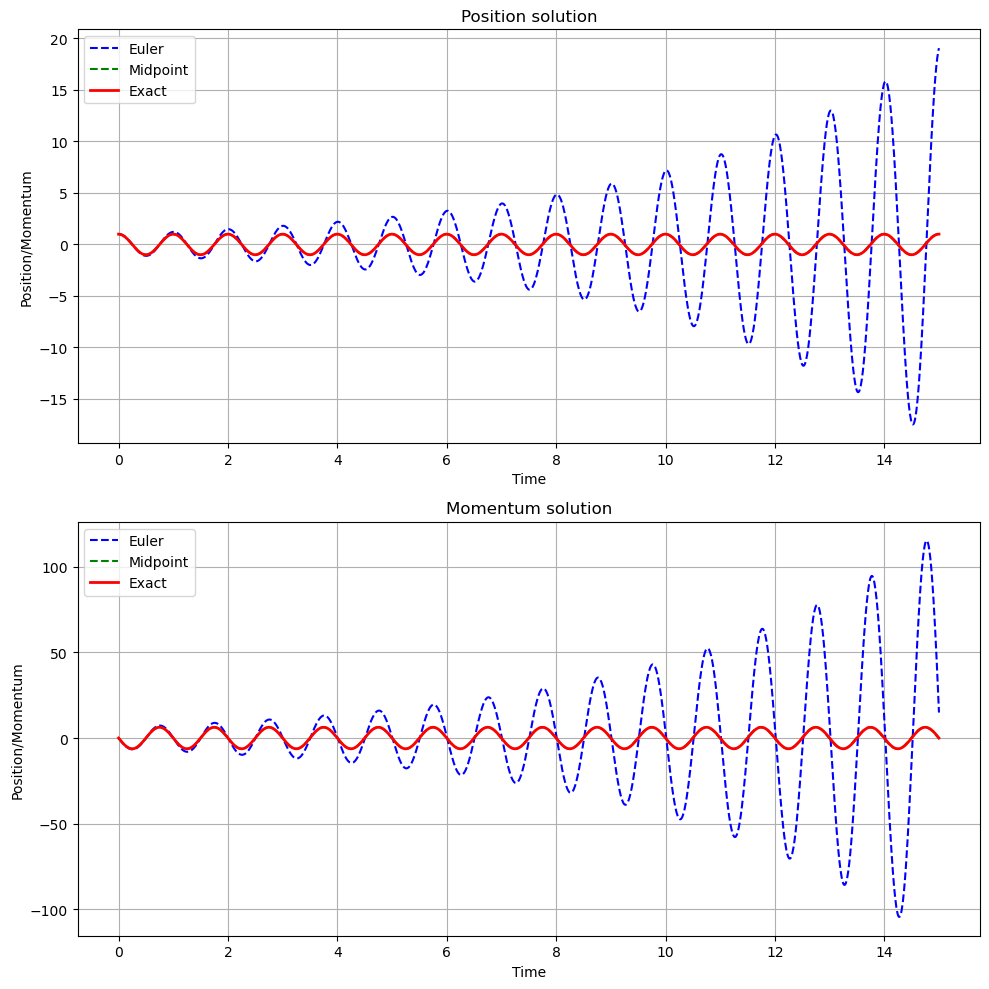

In [15]:
method_names = ["Euler", "Midpoint", "RK4"]
titles = ["Position", "Momentum"]
colors = ["blue", "green"]

plt.figure(figsize=(10, 5*len(methods)))

for i in range(len(xi)):
    plt.subplot(len(xi), 1, i+1)

    for j in range(len(methods)):
        plt.plot(ts, xs2[:, i, j], 'r--', color = colors[j], label = method_names[j])
    
    plt.plot(ts, exact2s[:, i], linewidth = 2, color = "red", label = "Exact")
    
    plt.xlabel("Time")
    plt.ylabel("Position/Momentum")
    plt.title(f"{titles[i]} solution")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

**Part (b)**

Solving through different methods for different h values

In [ ]:
# Defining parameters
ni, nf = -4, -2
step = 0.2

# Initialising h value array, array for storing errors and exact value of final point
hs = 10 ** np.arange(ni, nf + step, step)
errors = np.zeros((len(hs), len(xi), len(methods)))
exact_final = exact2(tf)
xf_hs2 = np.zeros((len(hs), len(xi), len(methods)))

# Calculating errors for various h values
for i in range(len(hs)):
    h = hs[i]
    N = int((tf - ti)/h) + 1
    ts = np.linspace(ti, tf, N)

    for j in range(len(methods)):
        xs_method = caller(f2, ts, xi, N, h, methods[j])
        xf_hs2[i, :, j] = xs_method[-1] 
        errors[i, :, j] = abs(xs_method[-1] - exact_final)

Viewing end points data in pandas Dataframe

In [17]:
# Position
data2_pf = np.column_stack((hs, xf_hs2[:, 0, :], [exact_final[0]]*len(hs)))
col_names_f = [f"{labels[i]}" for i in range(len(methods))]
col_names_f.append("Exact")
col_names_f.insert(0, "h")

df2_pf = pd.DataFrame(data2_pf, columns=col_names_f)
print(df2_pf)
print()

# Momentum
data2_vf = np.column_stack((hs, xf_hs2[:, 1, :], [exact_final[1]]*len(hs)))
df2_vf = pd.DataFrame(data2_vf, columns=col_names_f)
print(df2_vf)

           h      Euler  Midpoint  Exact
0   0.000100   1.030052  1.000000    1.0
1   0.000158   1.048045  1.000000    1.0
2   0.000251   1.077209  1.000000    1.0
3   0.000398   1.125101  1.000000    1.0
4   0.000631   1.205401  1.000000    1.0
5   0.001000   1.344516  0.999987    1.0
6   0.001585   1.598722  1.000010    1.0
7   0.002512   2.103116  1.000030    1.0
8   0.003981   3.245612  1.000125    1.0
9   0.006310   6.452604  1.000671    1.0
10  0.010000  18.832662  1.002924    1.0

           h      Euler  Midpoint         Exact
0   0.000100   0.000080 -0.000039  6.772877e-14
1   0.000158   0.004151  0.003667  6.772877e-14
2   0.000251   0.001337  0.000504  6.772877e-14
3   0.000398   0.006632  0.004042  6.772877e-14
4   0.000631   0.015686  0.008360  6.772877e-14
5   0.001000   0.063557  0.035582  6.772877e-14
6   0.001585   0.067320  0.012749  6.772877e-14
7   0.002512   0.230115  0.035670  6.772877e-14
8   0.003981   0.824268  0.068676  6.772877e-14
9   0.006310   2.549137 -0.

**Part (c)**

Plotting errors of different methods

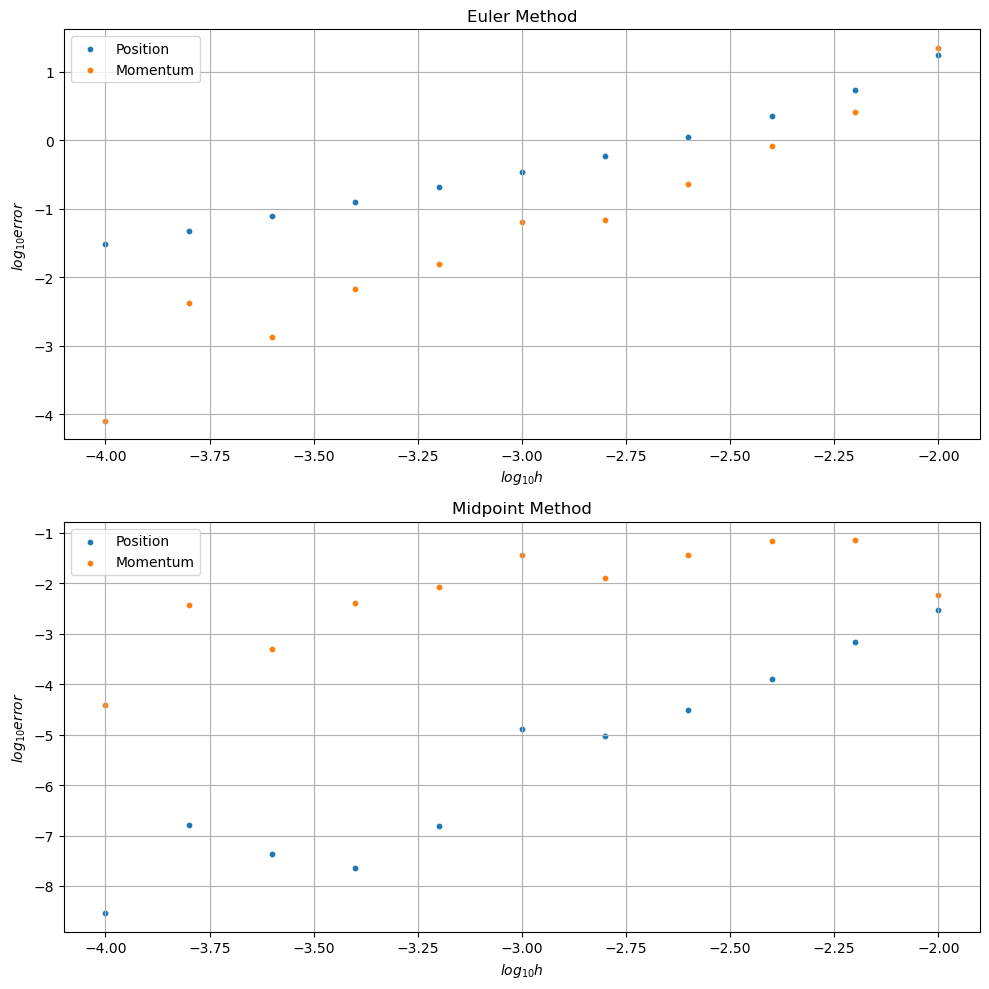

In [18]:
log_hs = np.log10(hs)
log_errors = np.log10(errors)
plt.figure(figsize=(10, 5*len(methods)))

for i in range(len(methods)):
    plt.subplot(len(methods), 1, i+1)
    plt.scatter(log_hs, log_errors[:, 0, i], s = 10, label = "Position")
    plt.scatter(log_hs, log_errors[:, 1, i], s = 10, label = "Momentum")
    plt.xlabel("$log_{10} h$")
    plt.ylabel("$log_{10} error$")
    plt.title(f"{labels[i]} Method")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

Fitting log error vs log h

In [19]:
slopes, intercepts = np.zeros((len(xi), len(methods))), np.zeros((len(xi), len(methods)))

for i in range(len(methods)):
    for j in range(len(xi)):
        popt, pcov = curve_fit(eqn_of_line, log_hs, log_errors[:, j, i])
        slope, intercept = popt
    
        slopes[j, i] = slope
        intercepts[j, i] = intercept

Plotting errors and fit for different methods for position

C:\Users\ARYA BASAK\AppData\Local\Temp\ipykernel_22552\2709323840.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(log_hs, eqn_of_line(log_hs, slopes[0, i], intercepts[0, i]), 'r--', color = colors[i], label = f"Slope = {slopes[0, i]: 0.2f}")


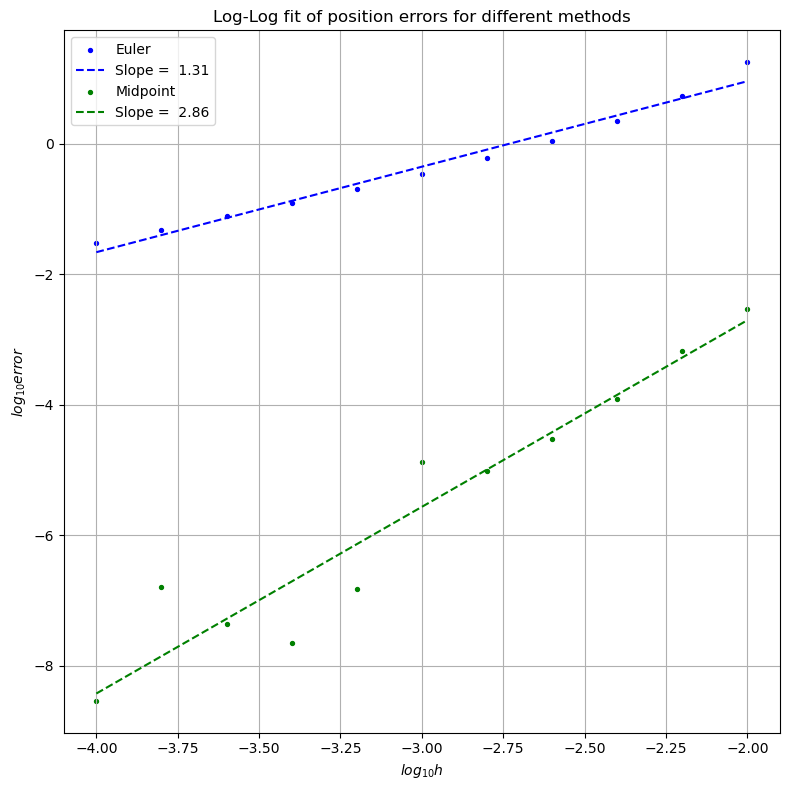

In [20]:
plt.figure(figsize=(8, 8))

for i in range(len(methods)):
    plt.scatter(log_hs, log_errors[:, 0, i], s = 8, color = colors[i], label = method_names[i])
    plt.plot(log_hs, eqn_of_line(log_hs, slopes[0, i], intercepts[0, i]), 'r--', color = colors[i], label = f"Slope = {slopes[0, i]: 0.2f}")
        
plt.xlabel("$log_{10} h$")
plt.ylabel("$log_{10} error$")
plt.title(f"Log-Log fit of position errors for different methods")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()